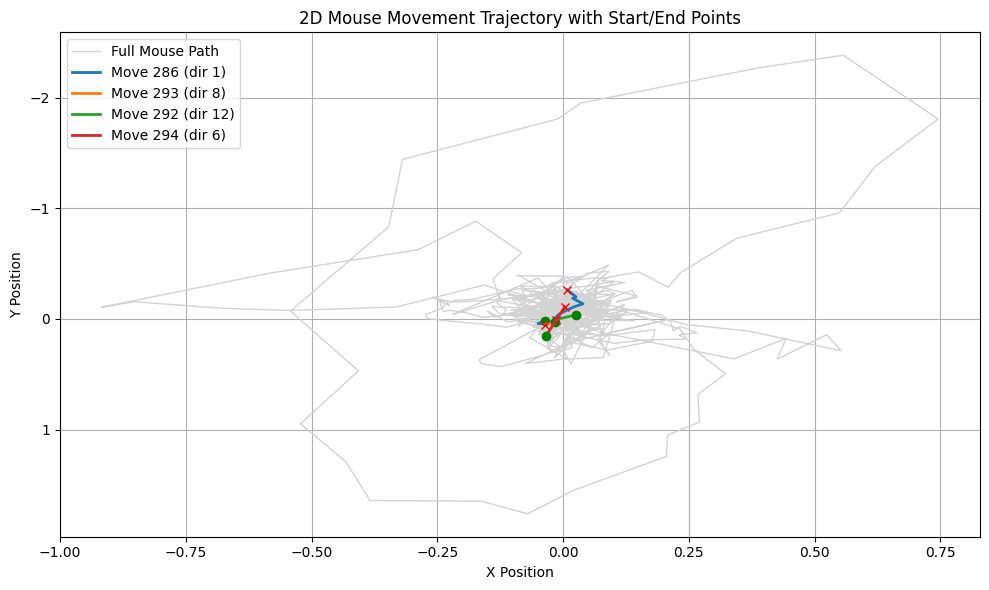

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3, os
import matplotlib.patches as mpatches  # Add this import

# Database connection
db_path = "DataCollection.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Get session data
session_id = "14"
cursor.execute("""
    SELECT StartTimestamp, EndTimestamp, DataFileName, StartMouseMovementID, EndMouseMovementID 
    FROM Sessions WHERE ID = ?""", (session_id,))
session_data = cursor.fetchone()
start_timestamp_db, end_timestamp_db, data_file_name, start_mouse_id, end_mouse_id = session_data

# Get mouse data
cursor.execute("""
    SELECT StartTimestamp, ENDTimestamp, Direction, ID
    FROM MouseMovement WHERE ID BETWEEN ? AND ? 
    ORDER BY StartTimestamp""", (start_mouse_id, end_mouse_id))
mouse_movements = cursor.fetchall()
conn.close()

# Load sensor data
df = pd.read_csv(data_file_name, header=None,
                 names=['timestamp', 'x', 'y', 'z'])

# Reconnect to update DB
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Ensure output folder exists
output_folder = f"SessionsData/MouseMovementData/session_{session_id}"
os.makedirs(output_folder, exist_ok=True)

# Iterate through mouse movements
for start_ts, end_ts, direction, mouse_id in mouse_movements:
    # Extract corresponding segment
    segment = df[(df['timestamp'] >= start_ts) & (df['timestamp'] <= end_ts)]
    
    # Save to file without header
    filename = f"{output_folder}/mouse_{mouse_id}.csv"
    segment.to_csv(filename, index=False, header=False)

    # Update database with filename
    cursor.execute("""
        UPDATE MouseMovement
        SET DataFileName = ?
        WHERE ID = ?
    """, (filename, mouse_id))

# Commit and close
conn.commit()
conn.close()




# Normalize time (in milliseconds from start)
start_time = min(df['timestamp'].min(), min(m[0] for m in mouse_movements))
df['time_ms'] = (df['timestamp'] - start_time) / 1000.0
mouses_ms = [
    ((s - start_time) / 1000.0, (e - start_time) / 1000.0, direction, mid)
    for s, e, direction, mid in mouse_movements
]

# --- Plot 2D trajectory ---
plt.figure(figsize=(10, 6))
plt.plot(df['x'], df['y'], color='lightgray', linewidth=1, label='Full Mouse Path')

# Plot each mouse movement segment
for start_ts, end_ts, direction, movement_id in mouse_movements:
    segment = df[(df['timestamp'] >= start_ts) & (df['timestamp'] <= end_ts)]
    if not segment.empty:
        plt.plot(segment['x'], segment['y'], linewidth=2, label=f'Move {movement_id} (dir {direction})')

        # Start point
        plt.plot(segment.iloc[0]['x'], segment.iloc[0]['y'], 'go', label='Start' if movement_id == mouse_movements[0][3] else "")
        # End point
        plt.plot(segment.iloc[-1]['x'], segment.iloc[-1]['y'], 'rx', label='End' if movement_id == mouse_movements[0][3] else "")

# Configure plot
plt.title("2D Mouse Movement Trajectory with Start/End Points")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.gca().invert_yaxis()  # Y grows downward on screens
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



8656 -580 9236


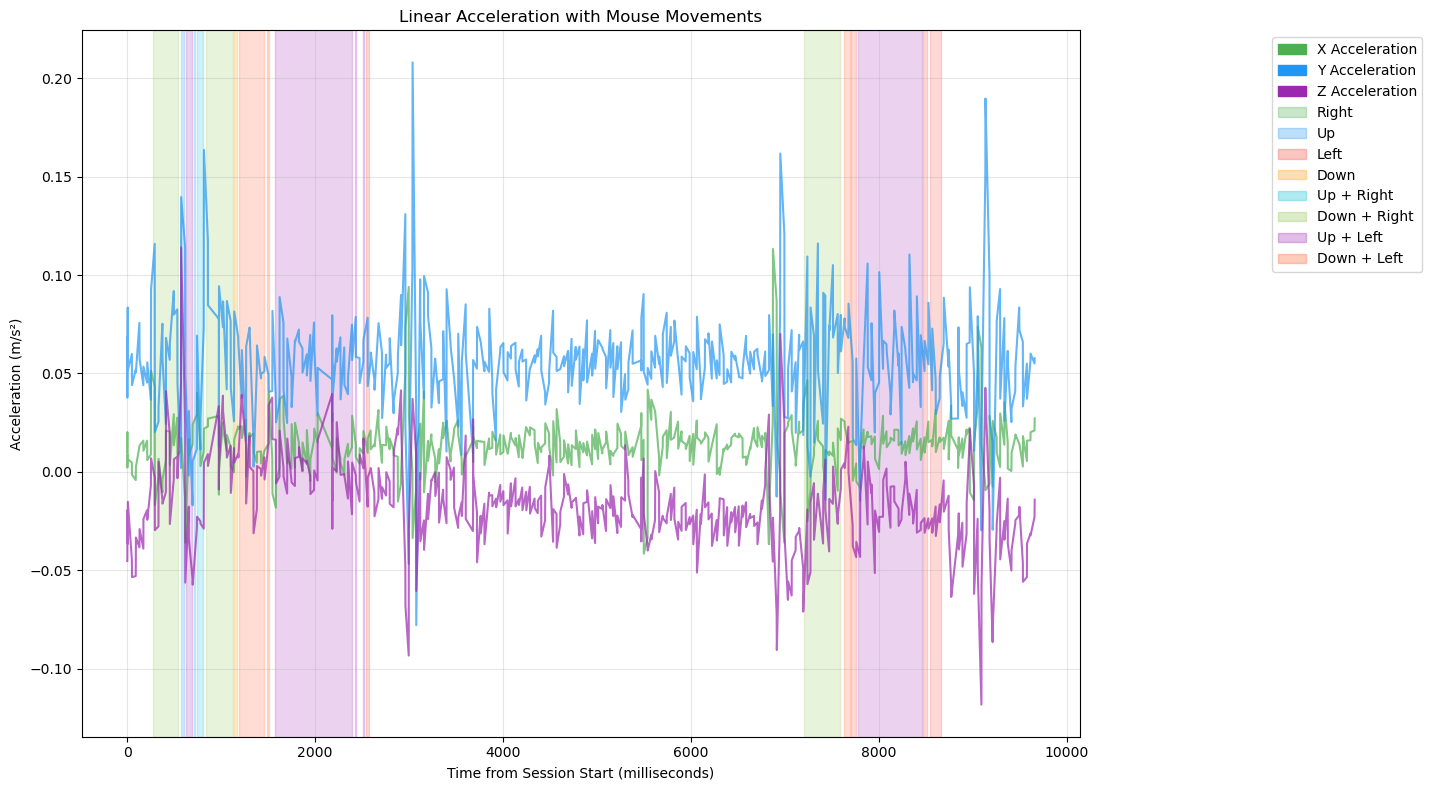

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3, uuid
import matplotlib.patches as mpatches  # Add this import

# Database connection
db_path = "DataCollection.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Get session data
session_id = "155"
cursor.execute("""
    SELECT StartTimestamp, EndTimestamp, DataFileName, StartKeyID, EndKeyID 
    FROM Sessions WHERE ID = ?""", (session_id,))
session_data = cursor.fetchone()
start_timestamp_db, end_timestamp_db, data_file_name, start_mouse_id, end_mouse_id = session_data

# Get mouse data
cursor.execute("""
    SELECT ID, StartTimestamp, ENDTimestamp, Direction 
    FROM MouseMovement WHERE ID BETWEEN ? AND ? 
    ORDER BY StartTimestamp""", (start_mouse_id, end_mouse_id))
mouses = cursor.fetchall()
conn.close()

# Load sensor data
df = pd.read_csv(data_file_name, header=None,
                 names=['timestamp', 'x', 'y', 'z'])


# Convert sensor timestamps (sensor time system)
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')

# Convert timestamps to relative seconds from session start
df['rel_time'] = (df['timestamp'] - df['timestamp'].iloc[0])  # Convert ms to seconds


last_timestamp = df['rel_time'].iloc[-1] - 1000
last_rel_timestamp_mouse = mouses[-1][2] - mouses[0][1]
time_shift = last_timestamp - last_rel_timestamp_mouse
print(last_timestamp, time_shift, last_rel_timestamp_mouse)


# Convert mouse events to relative time with direction decomposition
scrolls_relative = []
for mouse in mouses:
    mouse_id, mouse_start, mouse_end, direction = mouse
    rel_start = (mouse_start - start_timestamp_db) + time_shift
    rel_end = (mouse_end - start_timestamp_db) + time_shift
    if rel_start < 0 or (rel_end == rel_start):
        continue
    scrolls_relative.append((mouse_id, rel_start, rel_end, direction))



# Update the base_colors and get_direction_color function
direction_colors = {
    1: ('Right', '#4CAF50'),        # Green
    2: ('Up', '#2196F3'),           # Blue
    4: ('Left', '#F44336'),         # Red
    8: ('Down', '#FF9800'),         # Orange
    3: ('Up + Right', '#00BCD4'),   # Cyan (2+1)
    
    9: ('Down + Right', '#8BC34A'), # Light Green (8+1)
    6: ('Up + Left', '#9C27B0'),    # Same as 5 for consistency
    
    12: ('Down + Left', '#FF5722'), # Same as 10
    7: ('Up + Left + Right', '#607D8B'),    # Blue Grey
    15: ('All Directions', '#795548')       # Brown
}

def get_direction_color(direction):
    """Get color for exact direction combination"""
    return direction_colors.get(direction, ('Unknown', '#808080'))[1]
# Create plot
plt.figure(figsize=(15, 8))

# Plot linear acceleration components
plt.plot(df['rel_time'], df['x'], label='X', color='#4CAF50', alpha=0.7)
plt.plot(df['rel_time'], df['y'], label='Y', color='#2196F3', alpha=0.7)
plt.plot(df['rel_time'], df['z'], label='Z', color='#9C27B0', alpha=0.7)

# Add mouse movement regions with blended colors
for _, start, end, dir in scrolls_relative:
    color = get_direction_color(dir)
    plt.axvspan(start, end, color=color, alpha=0.2)

# Create custom legend
accel_patches = [
    mpatches.Patch(color='#4CAF50', label='X Acceleration'),
    mpatches.Patch(color='#2196F3', label='Y Acceleration'),
    mpatches.Patch(color='#9C27B0', label='Z Acceleration')
]

# Base direction legend entries
direction_patches = [
    mpatches.Patch(color=color, label=name, alpha=0.3)
    for dir_code, (name, color) in direction_colors.items()
    if dir_code in [1, 2, 4, 8, 3, 5, 9, 10, 6, 12]  # Filter valid combinations
]

# Combined directions explanation
combined_patch = mpatches.Patch(color='#808080', label='Combined Directions (Blended Colors)', alpha=0.3)

plt.legend(
    handles=accel_patches + direction_patches,
    loc='upper right',
    bbox_to_anchor=(1.35, 1),
    ncol=1  # Use 2 columns for better layout
)

# Format plot
plt.title(f'Linear Acceleration with Mouse Movements')
plt.xlabel('Time from Session Start (milliseconds)')
plt.ylabel('Acceleration (m/s²)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

